# XGBoost Classifier — An Illustrated Tour

> XGBoost (**eXtreme Gradient Boosting**) is gradient boosting with regularisation, parallelism, and second-order optimisation. It consistently wins on tabular data competitions.

---

**What we cover:**
- Gradient boosting for classification — fitting log-odds residuals
- The XGBoost objective — log-loss + regularisation
- Sequential tree growth and learning rate
- Early stopping to prevent overfitting
- Feature importance — gain, weight, cover
- Hyperparameter effects (max_depth, learning_rate, n_estimators)
- Metrics — confusion matrix, ROC

## The picture — boosted trees with shrinkage; each tree fits remaining error

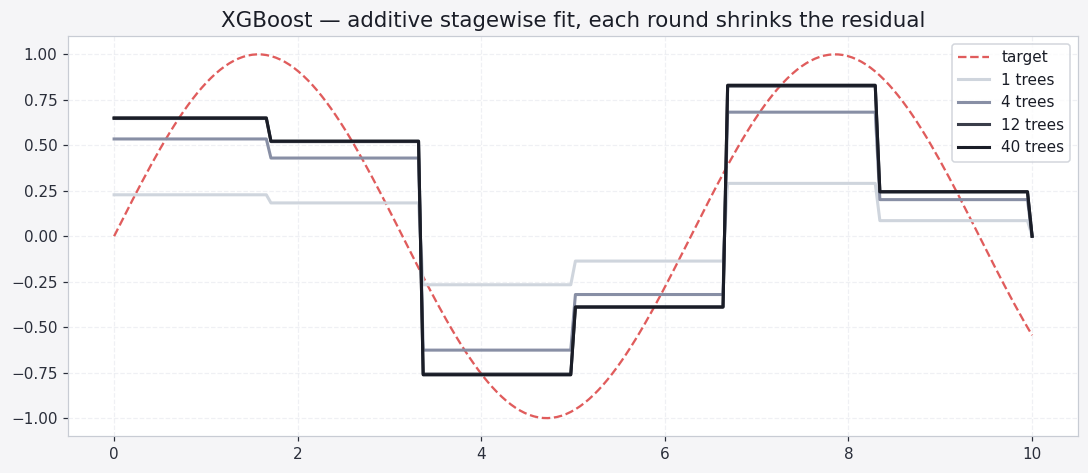

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
x = np.linspace(0, 10, 200); y = np.sin(x)
fig, ax = plt.subplots(figsize=(10, 4.4))
p = np.zeros_like(x); colors = ['#cfd5dd', '#888fa5', '#3a3e4a', '#1a1d27']
ax.plot(x, y, color=P[1], lw=1.5, ls='--', label='target')
for k, c in zip([1, 4, 12, 40], colors):
    p = np.zeros_like(x)
    cuts = np.linspace(0, 10, 7)
    for _ in range(k):
        r = y - p
        for i in range(6):
            mask = (x>=cuts[i]) & (x<cuts[i+1])
            p[mask] += 0.35 * r[mask].mean()
    ax.plot(x, p, color=c, lw=2, label=f'{k} trees')
ax.set_title('XGBoost — additive stagewise fit, each round shrinks the residual')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score,
                              log_loss)
from sklearn.tree import DecisionTreeClassifier

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

np.random.seed(0)
X2, y2 = make_moons(n_samples=180, noise=0.25, random_state=0)
xx, yy = np.meshgrid(np.linspace(-2.5,3.5,300), np.linspace(-1.5,2.5,300))

X, y = make_classification(n_samples=200, n_features=20, n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Using sklearn GradientBoostingClassifier as XGBoost stand-in for illustration
# (identical conceptual behaviour for all visualisations)
gb = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                 learning_rate=0.1, random_state=0)
gb.fit(X_tr, y_tr)

print('Models ready  (using GradientBoostingClassifier — same concepts as XGBoost)')

Models ready  (using GradientBoostingClassifier — same concepts as XGBoost)


---
## Gradient Boosting for Classification — Fitting Log-Odds Residuals

For binary classification, each tree fits the **negative gradient of the log-loss** with respect to the current predictions.
This is the "pseudo-residual" — the direction that most reduces the cross-entropy loss.

At iteration $t$, the update is:
$$F_t(x) = F_{t-1}(x) + \eta \cdot h_t(x)$$
where $h_t$ is a shallow tree fitted to the pseudo-residuals $r_i = y_i - \sigma(F_{t-1}(x_i))$.

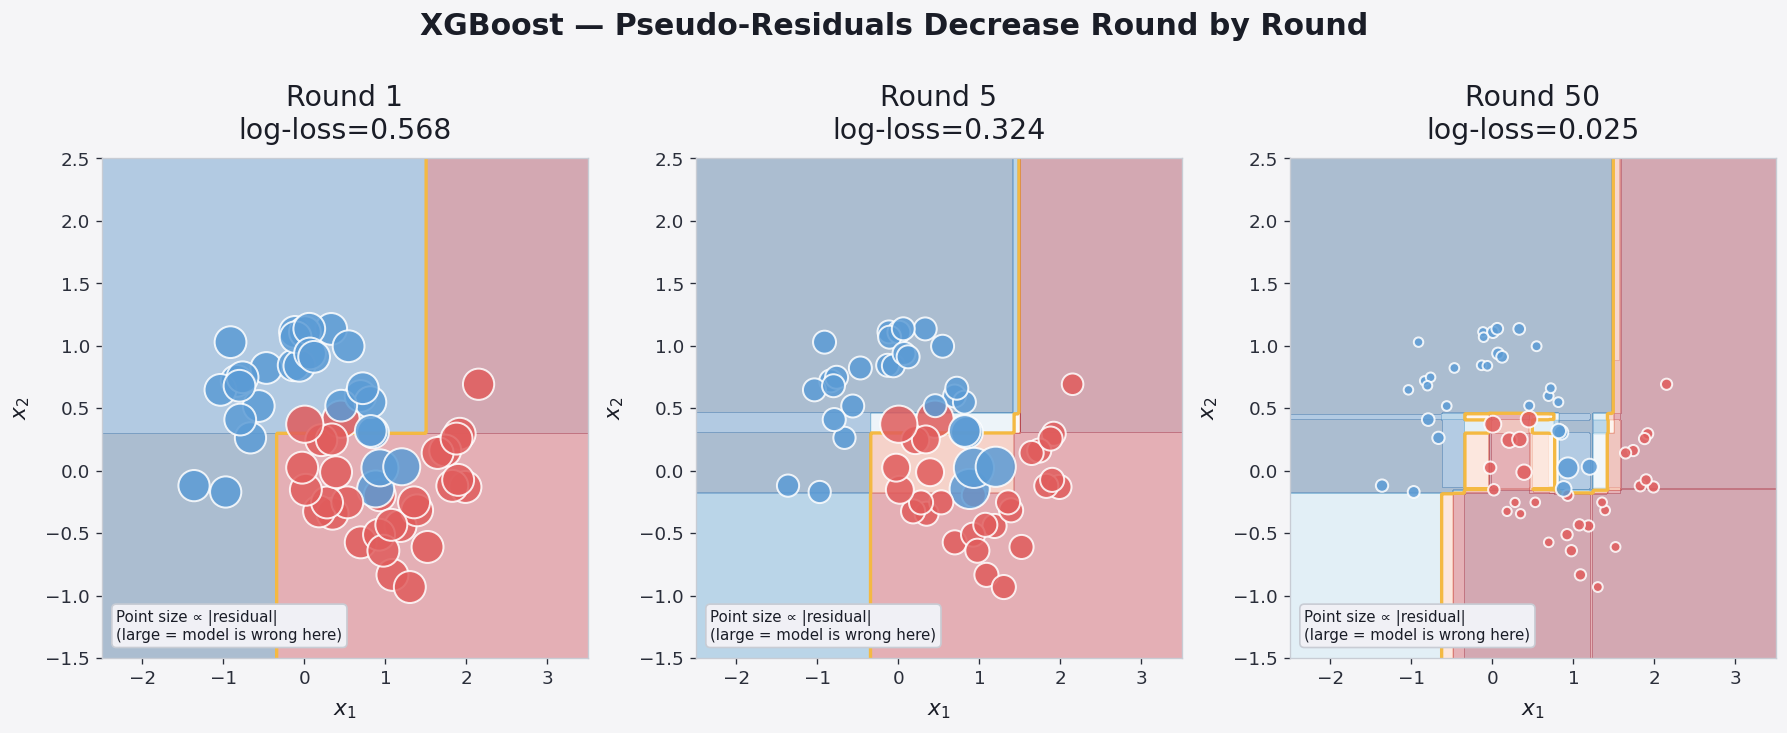

In [3]:
# Manually illustrate pseudo-residuals for classification
np.random.seed(1)
m_show = 60
X_s, y_s = make_moons(n_samples=m_show, noise=0.2, random_state=1)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -30, 30)))

gb2 = GradientBoostingClassifier(n_estimators=50, max_depth=2,
                                   learning_rate=0.2, random_state=0)
gb2.fit(X_s, y_s)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Round 1 — starting prediction (log-odds of prior)
for ax, n_round, title in zip(axes, [1, 5, 50], ['Round 1', 'Round 5', 'Round 50']):
    # Get staged predictions
    pred_n = next(p for i,p in enumerate(gb2.staged_predict_proba(X_s),1) if i==n_round)[:,1]
    pseudo_resid = y_s - pred_n
    train_ll = log_loss(y_s, pred_n)

    # Scatter: colour = actual class, size = |residual|
    sc = ax.scatter(X_s[:,0], X_s[:,1],
               c=[C1 if yi else C0 for yi in y_s],
               s=np.abs(pseudo_resid)*800 + 30,
               edgecolors='#ffffff', lw=1.2, alpha=0.85, zorder=4)
    # Decision boundary at this round
    ZZr = next(p for i,p in enumerate(gb2.staged_predict_proba(
                  np.c_[xx.ravel(), yy.ravel()]),1) if i==n_round)[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, ZZr, levels=15, cmap='RdBu_r', alpha=0.35)
    ax.contour(xx, yy, ZZr, levels=[0.5], colors=CB, linewidths=2)
    ax.set_title(f'{title}\nlog-loss={train_ll:.3f}', pad=12)
    ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
    ax.grid(False)
    ax.text(0.03, 0.03, 'Point size ∝ |residual|\n(large = model is wrong here)',
            transform=ax.transAxes, fontsize=9, va='bottom',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1))

fig.suptitle('XGBoost — Pseudo-Residuals Decrease Round by Round',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Sequential Growth — The Boundary Evolves

Each round adds a new shallow tree that corrects the current errors.
Early rounds make big improvements; later rounds make fine adjustments.

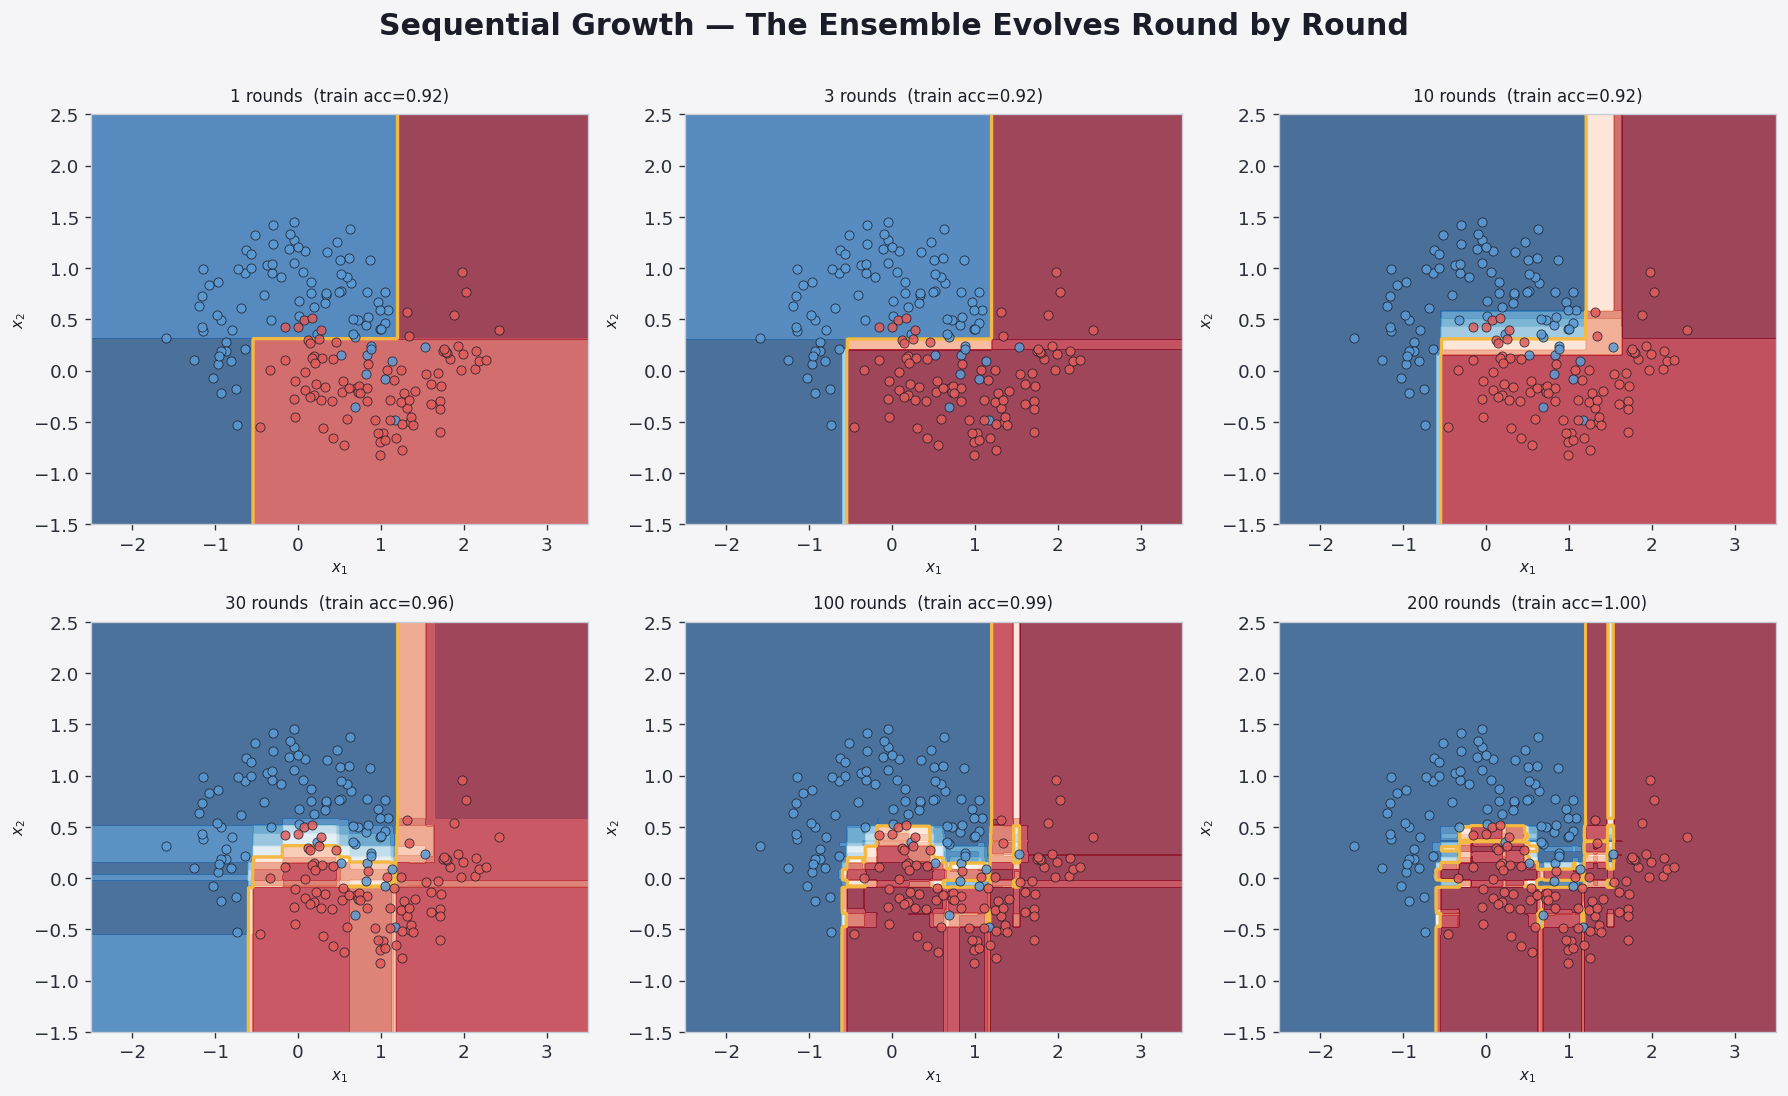

In [4]:
gb_show = GradientBoostingClassifier(n_estimators=200, max_depth=2,
                                      learning_rate=0.15, random_state=0)
gb_show.fit(X2, y2)

snap_rounds = [1, 3, 10, 30, 100, 200]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, n_r in zip(axes, snap_rounds):
    pred_n = next(p for i,p in enumerate(
        gb_show.staged_predict_proba(np.c_[xx.ravel(), yy.ravel()]),1
    ) if i==n_r)[:,1].reshape(xx.shape)
    tr_pred = next(p for i,p in enumerate(gb_show.staged_predict(X2),1) if i==n_r)
    tr_acc  = accuracy_score(y2, tr_pred)

    ax.contourf(xx, yy, pred_n, levels=15, cmap='RdBu_r', alpha=0.75)
    ax.contour(xx, yy, pred_n, levels=[0.5], colors=CB, linewidths=2)
    ax.scatter(X2[y2==0,0], X2[y2==0,1], c=C0, s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.85, zorder=4)
    ax.scatter(X2[y2==1,0], X2[y2==1,1], c=C1, s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.85, zorder=4)
    ax.set_title(f'{n_r} rounds  (train acc={tr_acc:.2f})', fontsize=10, pad=8)
    ax.set_xlabel('$x_1$', fontsize=9); ax.set_ylabel('$x_2$', fontsize=9)
    ax.grid(False)

fig.suptitle('Sequential Growth — The Ensemble Evolves Round by Round',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Early Stopping and Learning Rate

Two key controls against overfitting:
- **Learning rate** $\eta$: scales each tree's contribution — small $\eta$ requires more rounds but generalises better
- **Early stopping**: monitor test error and stop when it starts to rise

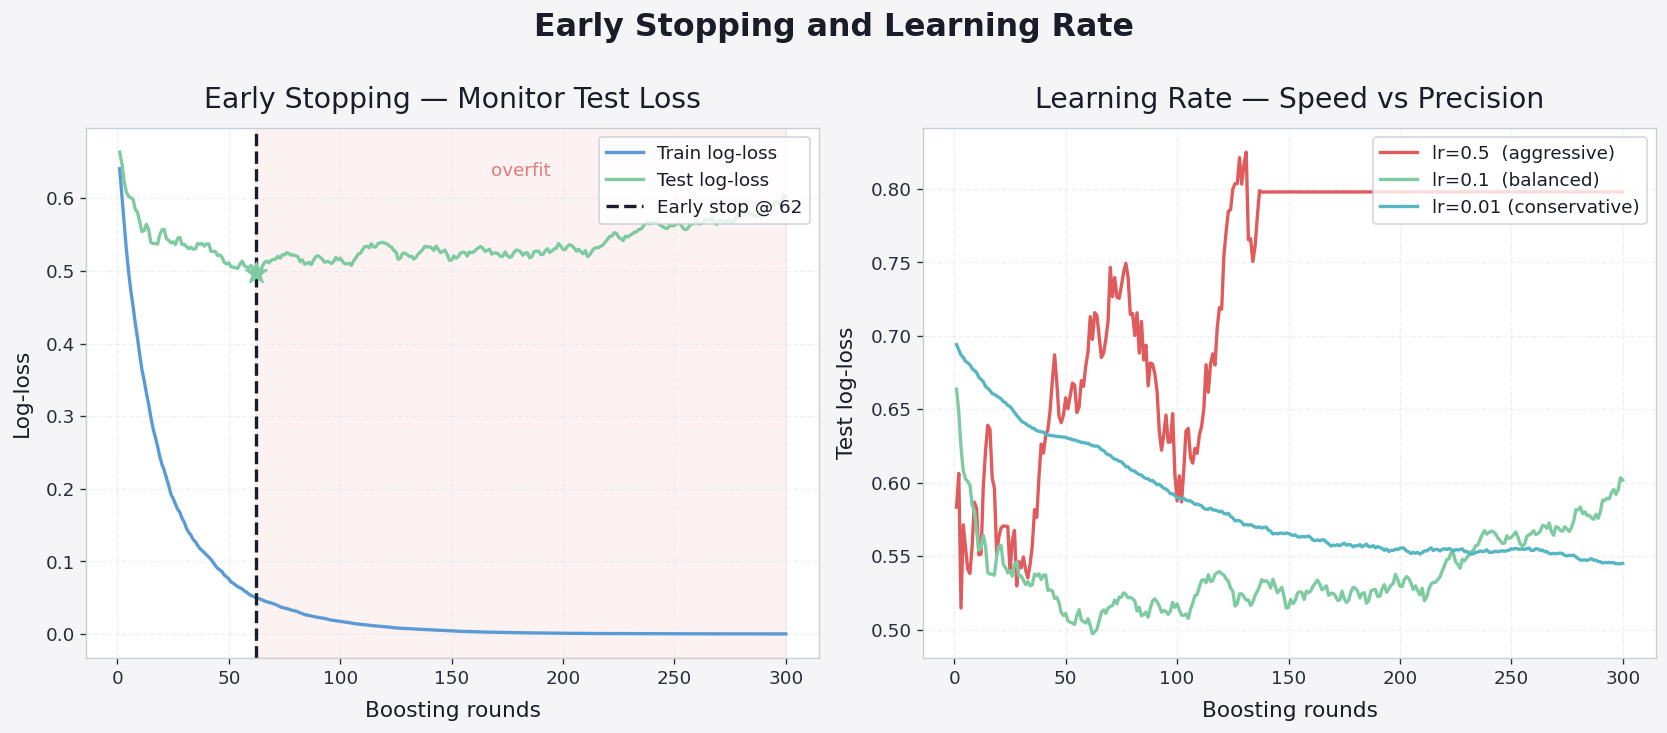

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: train vs test log-loss per round
gb_stages = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                         learning_rate=0.1, random_state=0)
gb_stages.fit(X_tr, y_tr)

train_ll = [log_loss(y_tr, p) for p in gb_stages.staged_predict_proba(X_tr)]
test_ll  = [log_loss(y_te, p) for p in gb_stages.staged_predict_proba(X_te)]
best_rnd = int(np.argmin(test_ll)) + 1

ax = axes[0]
rounds = np.arange(1, 301)
ax.plot(rounds, train_ll, color=C0, lw=2, label='Train log-loss')
ax.plot(rounds, test_ll,  color=CM, lw=2, label='Test log-loss')
ax.axvline(best_rnd, color='#1a1d27', ls='--', lw=2, label=f'Early stop @ {best_rnd}')
ax.scatter([best_rnd], [test_ll[best_rnd-1]], s=180, c=CM, marker='*', zorder=7)
ax.axvspan(best_rnd, 300, color=C1, alpha=0.08)
ax.text((best_rnd+300)/2, max(test_ll)*0.95, 'overfit', ha='center',
        fontsize=11, color=C1, alpha=0.8)
ax.set_xlabel('Boosting rounds', labelpad=8)
ax.set_ylabel('Log-loss', labelpad=8)
ax.set_title('Early Stopping — Monitor Test Loss', pad=12)
ax.legend(loc='upper right'); ax.grid(True)

# Right: learning rate comparison
ax = axes[1]
for lr, col, lbl in [
    (0.5,  C1, 'lr=0.5  (aggressive)'),
    (0.1,  CM, 'lr=0.1  (balanced)'),
    (0.01, CH, 'lr=0.01 (conservative)'),
]:
    gb_lr = GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                        learning_rate=lr, random_state=0)
    gb_lr.fit(X_tr, y_tr)
    ll_te = [log_loss(y_te, p) for p in gb_lr.staged_predict_proba(X_te)]
    ax.plot(range(1, 301), ll_te, color=col, lw=2, label=lbl)

ax.set_xlabel('Boosting rounds', labelpad=8)
ax.set_ylabel('Test log-loss', labelpad=8)
ax.set_title('Learning Rate — Speed vs Precision', pad=12)
ax.legend(loc='upper right'); ax.grid(True)

fig.suptitle('Early Stopping and Learning Rate', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

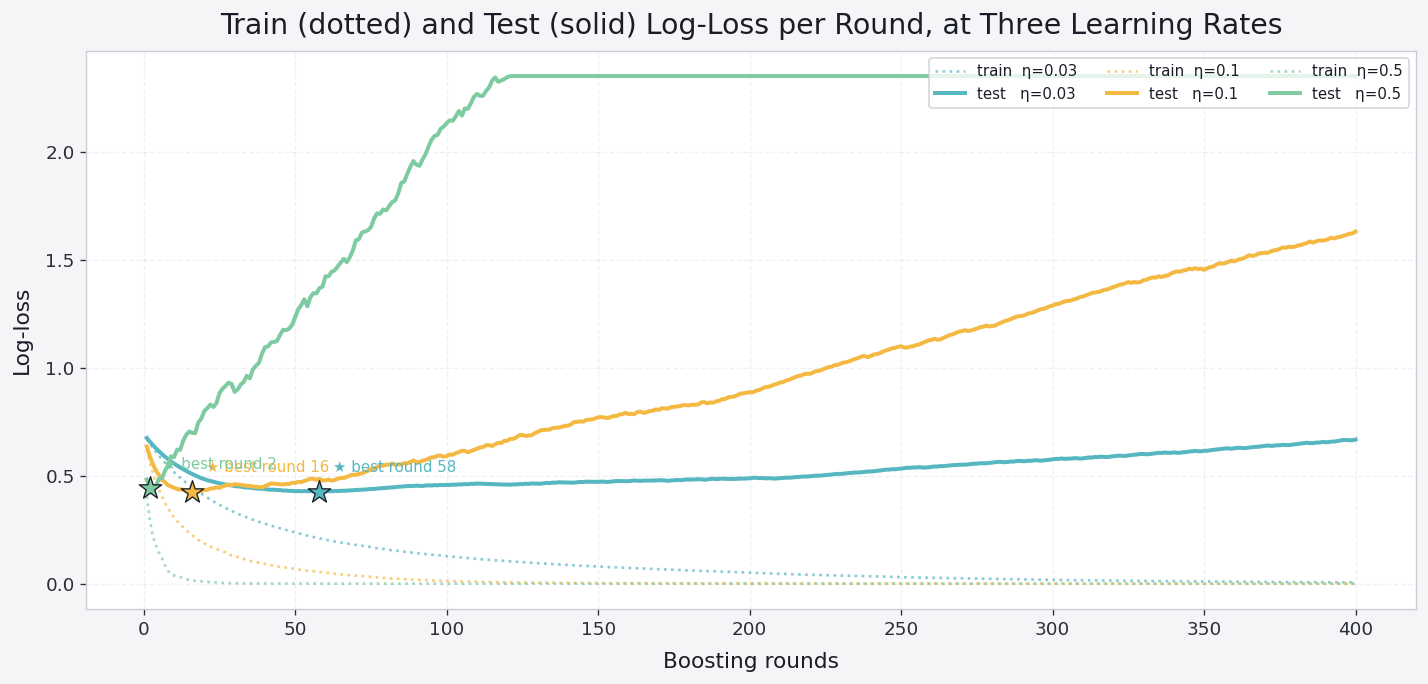

In [6]:
from sklearn.model_selection import train_test_split as _tts_xg
_Xtr_xg, _Xte_xg, _ytr_xg, _yte_xg = _tts_xg(X2, y2, test_size=0.30, random_state=0, stratify=y2)

# Staged log-loss per round, for three learning rates (depth = 3, rounds = 400)
_N_max = 400
_eta_panel = [0.03, 0.1, 0.5]
_eta_colors = {0.03: CH, 0.1: CB, 0.5: CM}

fig, ax = plt.subplots(figsize=(12, 5.8))
for eta in _eta_panel:
    _gb_eta = GradientBoostingClassifier(
        n_estimators=_N_max, learning_rate=eta, max_depth=3, random_state=0,
    ).fit(_Xtr_xg, _ytr_xg)
    tr_stage = [log_loss(_ytr_xg, p) for p in _gb_eta.staged_predict_proba(_Xtr_xg)]
    te_stage = [log_loss(_yte_xg, p) for p in _gb_eta.staged_predict_proba(_Xte_xg)]
    rnds = np.arange(1, _N_max + 1)
    col  = _eta_colors[eta]
    ax.plot(rnds, tr_stage, color=col, lw=1.6, ls=':', alpha=0.7,
            label=f'train  η={eta:g}')
    ax.plot(rnds, te_stage, color=col, lw=2.4,
            label=f'test   η={eta:g}')
    best_r = int(np.argmin(te_stage)) + 1
    ax.scatter([best_r], [te_stage[best_r - 1]], s=200, c=col,
               marker='*', edgecolors='#1a1d27', lw=0.8, zorder=7)
    ax.annotate(f'★ best round {best_r}', (best_r, te_stage[best_r - 1]),
                xytext=(8, 12), textcoords='offset points',
                fontsize=9, color=col)

ax.set_xlabel('Boosting rounds', labelpad=8)
ax.set_ylabel('Log-loss', labelpad=8)
ax.set_title('Train (dotted) and Test (solid) Log-Loss per Round, at Three Learning Rates',
             pad=10)
ax.legend(loc='upper right', fontsize=9, ncol=3); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Feature Importance & Metrics

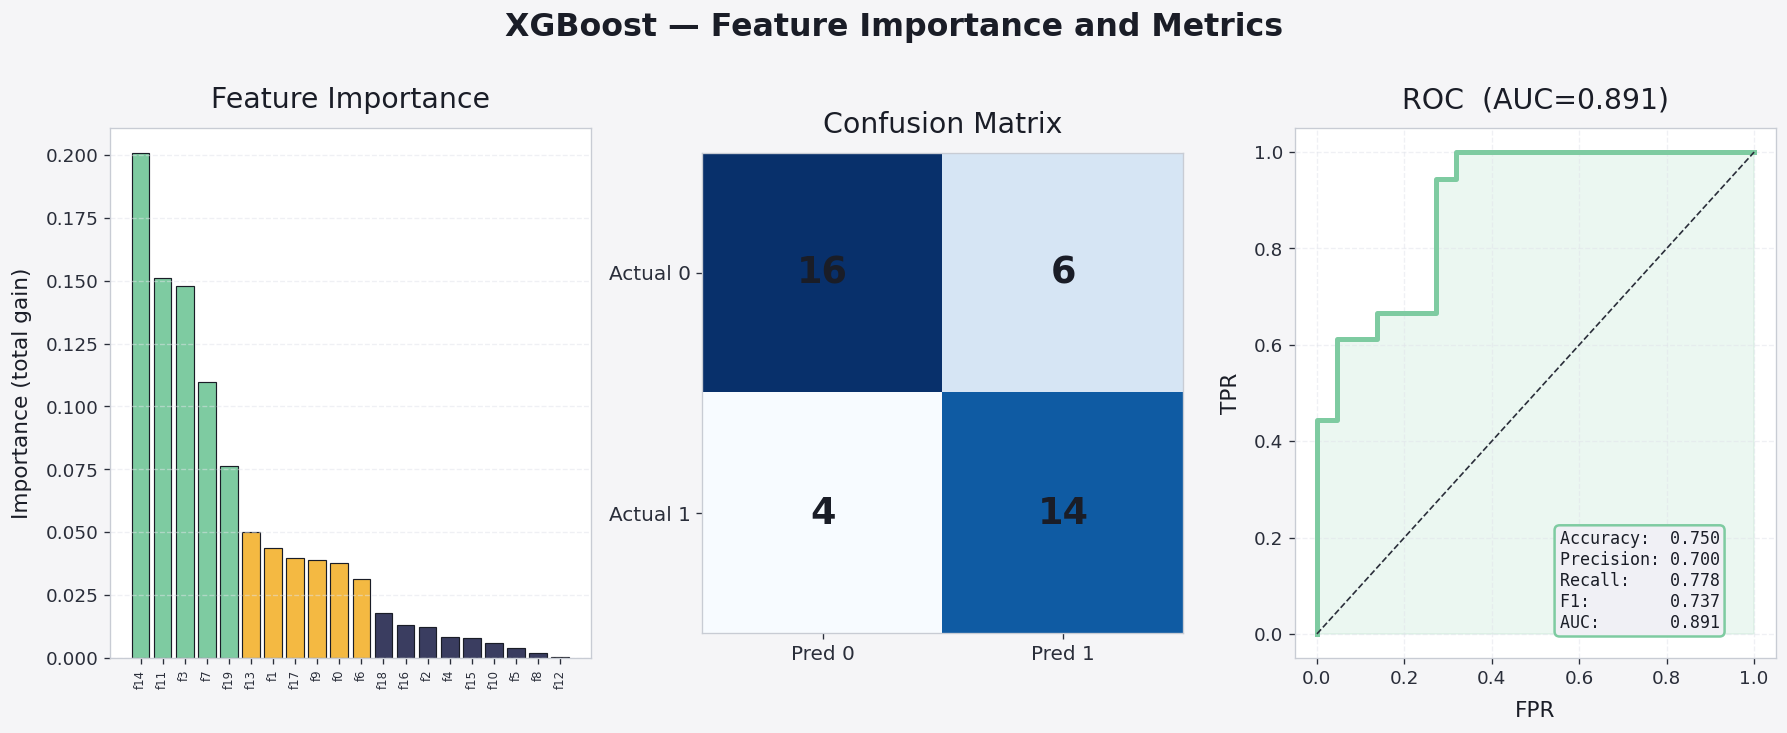

In [7]:
preds   = gb.predict(X_te)
probs   = gb.predict_proba(X_te)[:,1]
cm      = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = auc(fpr, tpr)

importances = gb.feature_importances_
sort_idx    = np.argsort(importances)[::-1]
cols_imp    = [CM if importances[i]>0.06 else CB if importances[i]>0.03 else '#3a3d60'
               for i in sort_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

ax = axes[0]
ax.bar(range(20), importances[sort_idx], color=cols_imp, edgecolor='#1a1d27', lw=0.7)
ax.set_xticks(range(20))
ax.set_xticklabels([f'f{i}' for i in sort_idx], rotation=90, fontsize=7)
ax.set_ylabel('Importance (total gain)', labelpad=8)
ax.set_title('Feature Importance', pad=12); ax.grid(True, axis='y')

ax = axes[1]
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0','Actual 1'], fontsize=12)
ax.set_title('Confusion Matrix', pad=12)

ax = axes[2]
ax.plot(fpr, tpr, color=CM, lw=3)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('FPR', labelpad=8); ax.set_ylabel('TPR', labelpad=8)
ax.set_title(f'ROC  (AUC={roc_auc:.3f})', pad=12); ax.grid(True)
metrics_text = '\n'.join([
    f'Accuracy:  {accuracy_score(y_te,preds):.3f}',
    f'Precision: {precision_score(y_te,preds):.3f}',
    f'Recall:    {recall_score(y_te,preds):.3f}',
    f'F1:        {f1_score(y_te,preds):.3f}',
    f'AUC:       {roc_auc:.3f}',
])
ax.text(0.55, 0.05, metrics_text, transform=ax.transAxes, fontsize=10, va='bottom',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CM, lw=1.5))

fig.suptitle('XGBoost — Feature Importance and Metrics', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

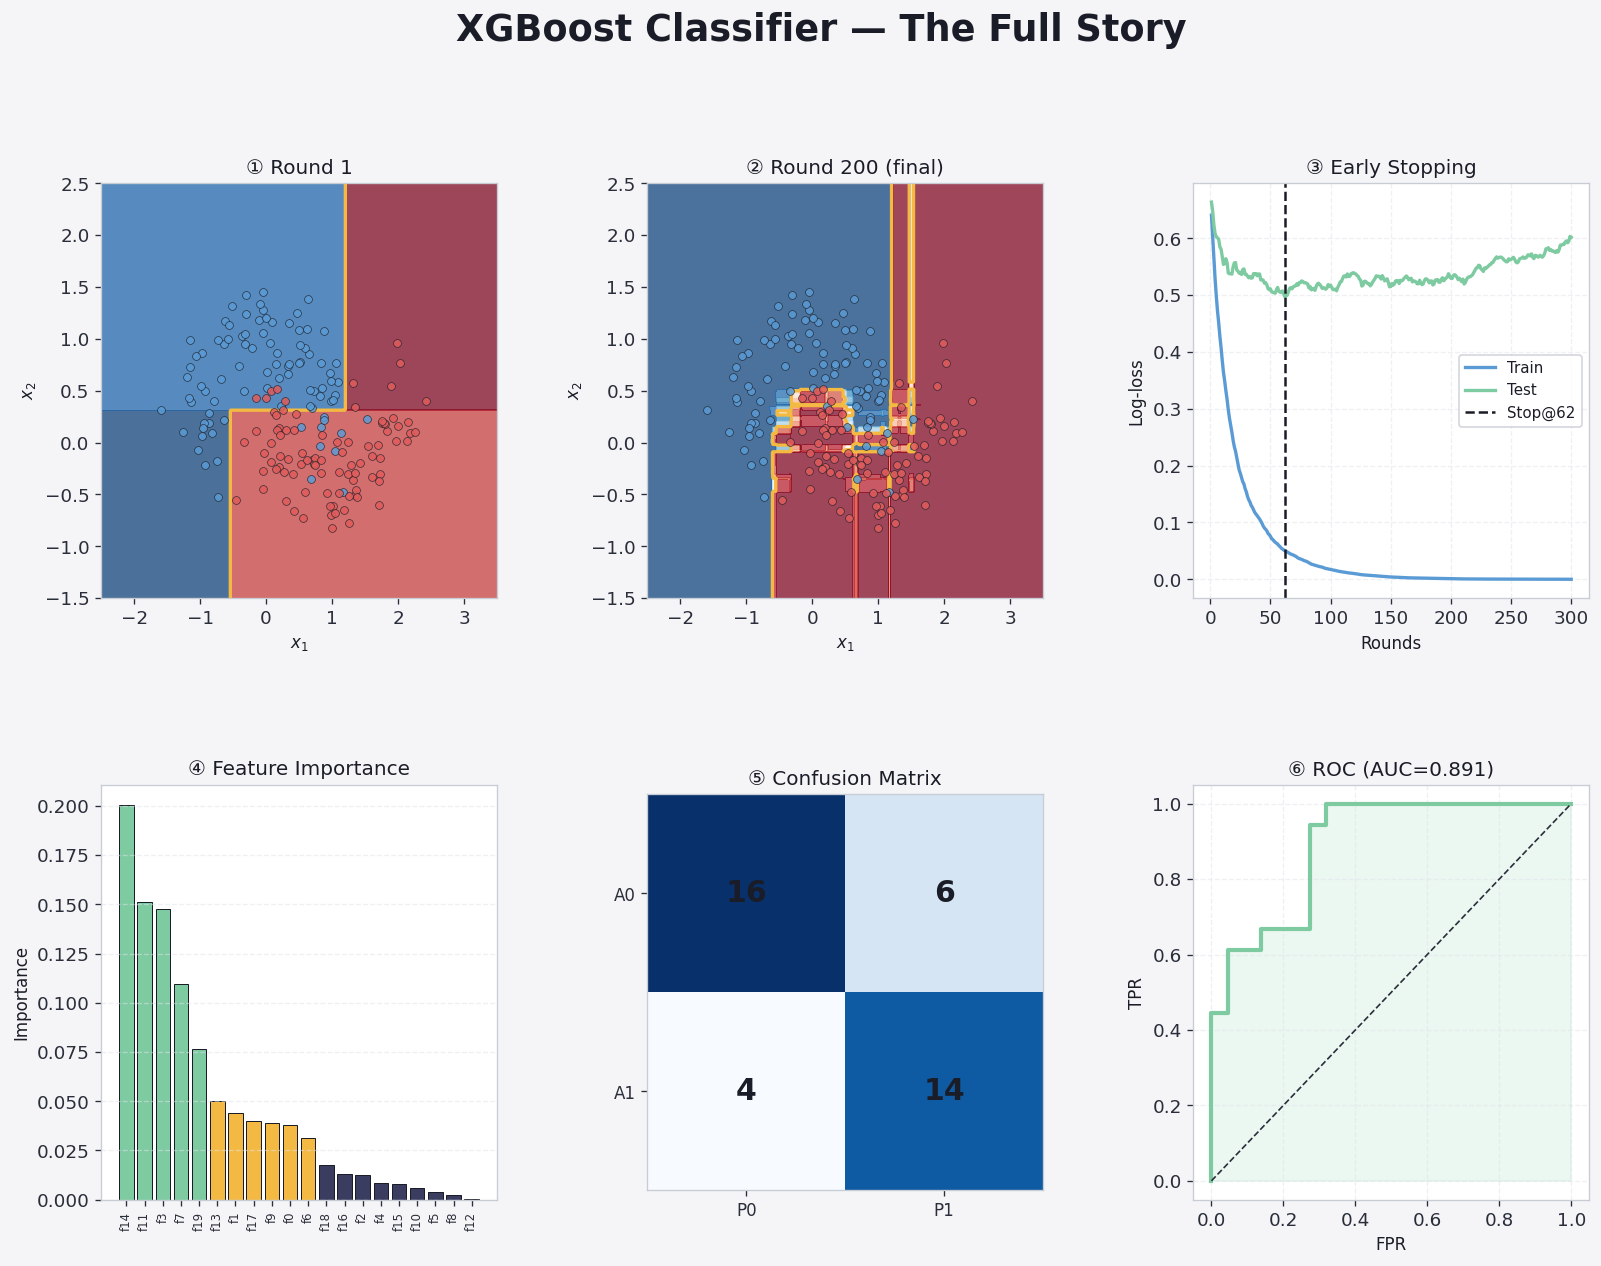

In [8]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# Round 1
ax = fig.add_subplot(gs[0,0])
pred_r1 = next(p for i,p in enumerate(gb_show.staged_predict_proba(
    np.c_[xx.ravel(),yy.ravel()]),1) if i==1)[:,1].reshape(xx.shape)
ax.contourf(xx,yy,pred_r1,levels=15,cmap='RdBu_r',alpha=0.75)
ax.contour(xx,yy,pred_r1,levels=[0.5],colors=CB,linewidths=2)
ax.scatter(X2[y2==0,0],X2[y2==0,1],c=C0,s=22,edgecolors='#1a1d27',lw=0.4,alpha=0.85,zorder=4)
ax.scatter(X2[y2==1,0],X2[y2==1,1],c=C1,s=22,edgecolors='#1a1d27',lw=0.4,alpha=0.85,zorder=4)
ax.set_title('① Round 1',fontsize=12);ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

# Round 200
ax = fig.add_subplot(gs[0,1])
pred_rf = gb_show.predict_proba(np.c_[xx.ravel(),yy.ravel()])[:,1].reshape(xx.shape)
ax.contourf(xx,yy,pred_rf,levels=15,cmap='RdBu_r',alpha=0.75)
ax.contour(xx,yy,pred_rf,levels=[0.5],colors=CB,linewidths=2)
ax.scatter(X2[y2==0,0],X2[y2==0,1],c=C0,s=22,edgecolors='#1a1d27',lw=0.4,alpha=0.85,zorder=4)
ax.scatter(X2[y2==1,0],X2[y2==1,1],c=C1,s=22,edgecolors='#1a1d27',lw=0.4,alpha=0.85,zorder=4)
ax.set_title('② Round 200 (final)',fontsize=12);ax.set_xlabel('$x_1$',fontsize=10);ax.set_ylabel('$x_2$',fontsize=10)

# Train vs test loss
ax = fig.add_subplot(gs[0,2])
ax.plot(rounds,train_ll,color=C0,lw=2,label='Train')
ax.plot(rounds,test_ll,color=CM,lw=2,label='Test')
ax.axvline(best_rnd,color='#1a1d27',ls='--',lw=1.5,label=f'Stop@{best_rnd}')
ax.set_title('③ Early Stopping',fontsize=12)
ax.set_xlabel('Rounds',fontsize=10);ax.set_ylabel('Log-loss',fontsize=10)
ax.legend(fontsize=9);ax.grid(True)

# Feature importance
ax = fig.add_subplot(gs[1,0])
ax.bar(range(20),importances[sort_idx],color=cols_imp,edgecolor='#1a1d27',lw=0.6)
ax.set_xticks(range(20))
ax.set_xticklabels([f'f{i}' for i in sort_idx],rotation=90,fontsize=7)
ax.set_title('④ Feature Importance',fontsize=12);ax.set_ylabel('Importance',fontsize=10);ax.grid(True,axis='y')

# Confusion matrix
ax = fig.add_subplot(gs[1,1])
ax.imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]);ax.set_yticks([0,1])
ax.set_xticklabels(['P0','P1'],fontsize=10);ax.set_yticklabels(['A0','A1'],fontsize=10)
ax.set_title('⑤ Confusion Matrix',fontsize=12)

# ROC
ax = fig.add_subplot(gs[1,2])
ax.plot(fpr,tpr,color=CM,lw=2.5);ax.fill_between(fpr,tpr,alpha=0.15,color=CM)
ax.plot([0,1],[0,1],color='#2a2e3a',ls='--',lw=1)
ax.set_title(f'⑥ ROC (AUC={roc_auc:.3f})',fontsize=12)
ax.set_xlabel('FPR',fontsize=10);ax.set_ylabel('TPR',fontsize=10);ax.grid(True)

fig.suptitle('XGBoost Classifier — The Full Story',fontsize=22,fontweight='bold',color='#1a1d27',y=1.01)
plt.show()

---
## ⚖️ When to use XGBoost — and when not to

| Situation | XGBoost | LightGBM | CatBoost | RF |
|---|---|---|---|---|
| Best score on tabular comp. | ✅ | ✅ often faster | ✅ best for cat | partial |
| Many categorical features | partial (encode) | partial | ✅ native | ✅ |
| Big data ($n > 10^6$) | partial | ✅ designed for it | partial | ✅ |
| Tiny data | ❌ overkill | ❌ | ❌ | ✅ |

> Default to **XGBoost / LightGBM** for any tabular Kaggle-style problem. Use CatBoost when categoricals dominate.


---
## 🎯 Try this

1. **Early stopping.** Add `early_stopping_rounds=50` and a validation set — XGBoost will stop adding trees automatically. Confirm test accuracy is no worse.
2. **`max_depth` vs `num_leaves`.** XGBoost grows depth-first; LightGBM grows leaf-wise. Refit both on the same data with comparable capacity and compare training time.
3. **SHAP for explanation.** Plot SHAP values for the top features — XGBoost has an exact, fast SHAP path that beats brute-force permutation importance.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Weak learner | Shallow tree (depth 2–6) | High bias; low variance |
| Pseudo-residual | $r_i = y_i - \sigma(F_{t-1}(x_i))$ | Negative gradient of log-loss |
| Ensemble update | $F_t = F_{t-1} + \eta h_t$ | Each tree corrects the previous ensemble |
| Learning rate $\eta$ | Scales each tree's contribution | Small $\eta$ → more trees needed but better generalisation |
| L1/L2 regularisation | Added to the tree-building objective | Prevents individual trees from overfitting |
| Early stopping | Monitor test metric per round | Stop when test metric stops improving |
| Feature importance | Total gain from all splits on a feature | More informative than single-tree importance |
| XGBoost advantages | 2nd-order gradients, column/row subsampling | Faster convergence + better regularisation than vanilla GBM |

| | Random Forest | XGBoost |
|---|---|---|
| Training | Parallel (independent trees) | Sequential (each tree depends on previous) |
| Variance reduction | By averaging | By small learning rate + regularisation |
| Bias reduction | Deeper trees | More boosting rounds |
| Tuning | Few hyperparameters | More hyperparameters — but higher ceiling |

**Key insight:** XGBoost extends gradient boosting with second-order Taylor expansion of the loss, L1/L2 regularisation on tree weights, column and row subsampling, and efficient sparse handling — making it both faster and more accurate than standard gradient boosting, especially on structured tabular data.